
<a id='lln-clt'></a>

# LLN and CLT


<a id='index-3'></a>

## Contents

- [LLN and CLT](#LLN-and-CLT)  
  - [Overview](#Overview)  
  - [Relationships](#Relationships)  
  - [LLN](#LLN)  
  - [CLT](#CLT)  
  - [Exercises](#Exercises)  
  - [Solutions](#Solutions)  

## Overview

This lecture illustrates two of the most important theorems of probability and statistics: The
law of large numbers (LLN) and the central limit theorem (CLT).

These beautiful theorems lie behind many of the most fundamental results in econometrics and quantitative economic modeling.

The lecture is based around simulations that show the LLN and CLT in action.

We also demonstrate how the LLN and CLT break down when the assumptions they are based on do not hold.

In addition, we examine several useful extensions of the classical theorems, such as

- The delta method, for smooth functions of random variables  
- The multivariate case  


Some of these extensions are presented as exercises.

## Relationships

The CLT refines the LLN.

The LLN gives conditions under which sample moments converge to population moments as sample size increases.

The CLT provides information about the rate at which sample moments converge to population moments as sample size increases.


<a id='lln-mr'></a>

## LLN


<a id='index-4'></a>
We begin with the law of large numbers, which tells us when sample averages
will converge to their population means.


<a id='lln-ksl'></a>

### The Classical LLN

The classical law of large numbers concerns independent and
identically distributed (IID) random variables.

Here is the strongest version of the classical LLN, known as *Kolmogorov’s strong law*.

Let $ X_1, \ldots, X_n $ be independent and identically
distributed scalar random variables, with common distribution $ F $.

When it exists, let $ \mu $ denote the common mean of this sample:

$$
\mu := \mathbb E X = \int x F(dx)
$$

In addition, let

$$
\bar X_n := \frac{1}{n} \sum_{i=1}^n X_i
$$

Kolmogorov’s strong law states that, if $ \mathbb E |X| $ is finite, then


<a id='equation-lln-as'></a>
$$
\mathbb P \left\{ \bar X_n \to \mu \text{ as } n \to \infty \right\} = 1 \tag{18.1}
$$

What does this last expression mean?

Let’s think about it from a simulation perspective, imagining for a moment that
our computer can generate perfect random samples (which of course [it can’t](https://en.wikipedia.org/wiki/Pseudorandom_number_generator)).

Let’s also imagine that we can generate infinite sequences, so that the
statement $ \bar X_n \to \mu $ can be evaluated.

In this setting, [(18.1)](#equation-lln-as) should be interpreted as meaning that the
probability of the computer producing a sequence where $ \bar X_n \to \mu $ fails to occur
is zero.

### Proof


<a id='index-5'></a>
The proof of Kolmogorov’s strong law is nontrivial – see, for example, theorem 8.3.5 of [[Dud02](https://julia.quantecon.org/../zreferences.html#id77)].

On the other hand, we can prove a weaker version of the LLN very easily and
still get most of the intuition.

The version we prove is as follows: If $ X_1, \ldots, X_n $ is IID with $ \mathbb E X_i^2 < \infty $,
then, for any $ \epsilon > 0 $, we have


<a id='equation-lln-ip'></a>
$$
\mathbb P \left\{ | \bar X_n - \mu | \geq \epsilon \right\} \to 0
\quad \text{as} \quad
n \to \infty \tag{18.2}
$$

(This version is weaker because we claim only [convergence in probability](https://en.wikipedia.org/wiki/Convergence_of_random_variables#Convergence_in_probability) rather than [almost sure convergence](https://en.wikipedia.org/wiki/Convergence_of_random_variables#Almost_sure_convergence), and assume a finite second moment)

To see that this is so, fix $ \epsilon > 0 $, and let $ \sigma^2 $ be the variance of each $ X_i $.

Recall the [Chebyshev inequality](https://en.wikipedia.org/wiki/Chebyshev%27s_inequality), which tells us that


<a id='equation-lln-cheb'></a>
$$
\mathbb P \left\{ | \bar X_n - \mu | \geq \epsilon \right\}
\leq \frac{\mathbb E [ (\bar X_n - \mu)^2]}{\epsilon^2} \tag{18.3}
$$

Now observe that

$$
\begin{aligned}
    \mathbb E [ (\bar X_n - \mu)^2 ]
    & = \mathbb E \left\{ \left[
    \frac{1}{n} \sum_{i=1}^n (X_i - \mu)
    \right]^2 \right\}
    \\
    & = \frac{1}{n^2} \sum_{i=1}^n \sum_{j=1}^n \mathbb E (X_i - \mu)(X_j - \mu) \nonumber
    \\
    & = \frac{1}{n^2} \sum_{i=1}^n \mathbb E (X_i - \mu)^2 \nonumber
    \\
    & = \frac{\sigma^2}{n} \nonumber
\end{aligned}
$$

Here the crucial step is at the third equality, which follows from
independence.

Independence means that if $ i \not= j $, then the covariance term $ \mathbb E (X_i - \mu)(X_j - \mu) $ drops out.

As a result, $ n^2 - n $ terms vanish, leading us to a final expression that goes to zero in $ n $.

Combining our last result with [(18.3)](#equation-lln-cheb), we come to the estimate


<a id='equation-lln-cheb2'></a>
$$
\mathbb P \left\{ | \bar X_n - \mu | \geq \epsilon \right\}
\leq \frac{\sigma^2}{n \epsilon^2} \tag{18.4}
$$

The claim in [(18.2)](#equation-lln-ip) is now clear.

Of course, if the sequence $ X_1, \ldots, X_n $ is correlated, then the cross-product terms
$ \mathbb E (X_i - \mu)(X_j - \mu) $ are not necessarily zero.

While this doesn’t mean that the same line of argument is impossible, it does mean
that if we want a similar result then the covariances should be “almost zero”
for “most” of these terms.

In a long sequence, this would be true if, for example, $ \mathbb E (X_i - \mu)(X_j - \mu) $
approached zero when the difference between $ i $ and $ j $ became
large.

In other words, the LLN can still work if the sequence $ X_1, \ldots, X_n $ has a kind of “asymptotic independence”, in the sense that correlation falls to zero as variables become further apart in the sequence.

This idea is very important in time series analysis, and we’ll come across it again soon enough.

### Illustration


<a id='index-6'></a>
Let’s now illustrate the classical IID law of large numbers using simulation.

In particular, we aim to generate some sequences of IID random variables and plot the evolution
of $ \bar X_n $ as $ n $ increases.

Below is a figure that does just this (as usual, you can click on it to expand it).

It shows IID observations from three different distributions and plots $ \bar X_n $ against $ n $ in each case.

The dots represent the underlying observations $ X_i $ for $ i = 1, \ldots, 100 $.

In each of the three cases, convergence of $ \bar X_n $ to $ \mu $ occurs as predicted.

In [ ]:
Pkg.activate()

In [1]:
using LinearAlgebra, Statistics
using LaTeXStrings, Plots, Distributions, Random


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [2]:
function ksl(distribution, n = 100)
    title = nameof(typeof(distribution))
    observations = rand(distribution, n)
    sample_means = cumsum(observations) ./ (1:n)
    mu = mean(distribution)
    plot(repeat((1:n)', 2),
         [zeros(1, n); observations'], label = "", color = :grey, alpha = 0.5)
    plot!(1:n, observations, color = :grey, markershape = :circle,
          alpha = 0.5, label = "", linewidth = 0)
    if !isnan(mu)
        hline!([mu], color = :black, linewidth = 1.5, linestyle = :dash,
               grid = false,
               label = "Mean")
    end
    plot!(1:n, sample_means, linewidth = 3, alpha = 0.6, color = :green,
          label = "Sample mean")
    return plot!(title = title)
end

ksl (generic function with 2 methods)

In [3]:
distributions = [TDist(10), Beta(2, 2), Gamma(5, 2), Poisson(4), LogNormal(0.5),
    Exponential(1)]

6-element Vector{UnivariateDistribution}:
 TDist{Float64}(ν=10.0)
 Beta{Float64}(α=2.0, β=2.0)
 Gamma{Float64}(α=5.0, θ=2.0)
 Poisson{Float64}(λ=4.0)
 LogNormal{Float64}(μ=0.5, σ=1.0)
 Exponential{Float64}(θ=1.0)

Here is in an example for the standard normal distribution

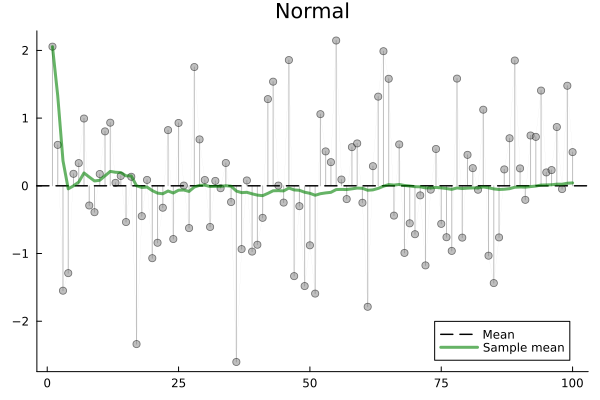

In [4]:
ksl(Normal())

In [10]:
Random.seed!(0); # reproducible results

In [12]:
rand()

0.06854582438651502

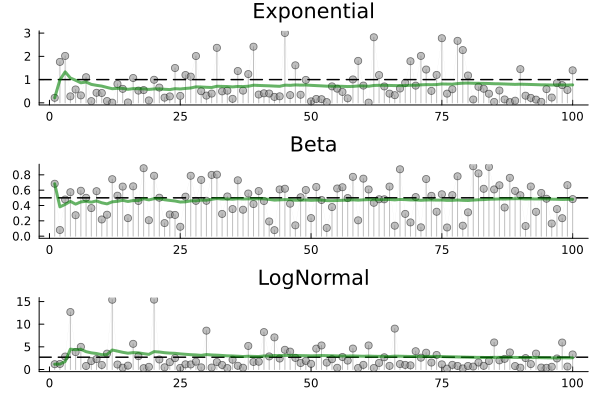

In [13]:
plot(ksl.(sample(distributions, 3, replace = false))..., layout = (3, 1),
     legend = false)

The three distributions are chosen at random from distributions.

### Infinite Mean

What happens if the condition $ \mathbb E | X | < \infty $ in the statement of the LLN is not satisfied?

This might be the case if the underlying distribution is heavy tailed — the best
known example is the Cauchy distribution, which has density

$$
f(x) = \frac{1}{\pi (1 + x^2)} \qquad (x \in \mathbb R)
$$

The next figure shows 100 independent draws from this distribution

In [14]:
Random.seed!(0); # reproducible results

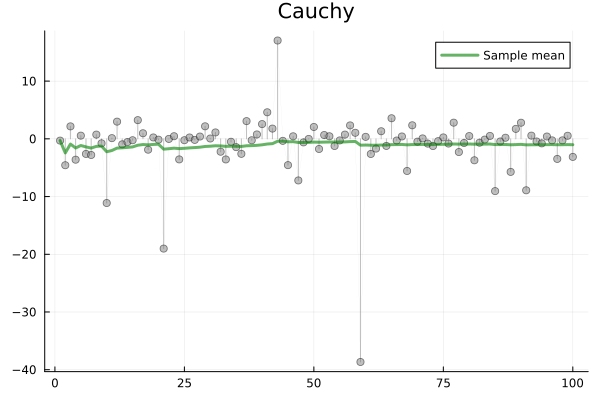

In [15]:
ksl(Cauchy())

Notice how extreme observations are far more prevalent here than the previous figure.

Let’s now have a look at the behavior of the sample mean

In [16]:
Random.seed!(0); # reproducible results

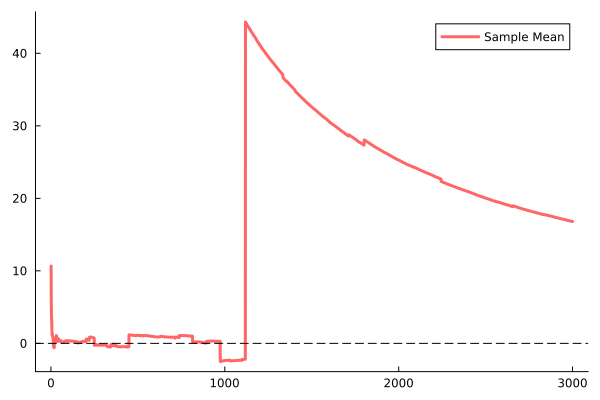

In [19]:
function plot_means(n = 3000)
    sample_mean = cumsum(rand(Cauchy(), n)) ./ (1:n)
    plot(1:n, sample_mean, color = :red, alpha = 0.6, label = "Sample Mean",
         linewidth = 3)
    return hline!([0], color = :black, linestyle = :dash, label = "", grid = false)
end

plot_means()

Here we’ve increased $ n $ to 1000, but the sequence still shows no sign of converging.

Will convergence become visible if we take $ n $ even larger?

The answer is no.

To see this, recall that the [characteristic function](https://en.wikipedia.org/wiki/Characteristic_function_%28probability_theory%29) of the Cauchy distribution is


<a id='equation-lln-cch'></a>
$$
\phi(t) = \mathbb E e^{itX} = \int e^{i t x} f(x) dx = e^{-|t|} \tag{18.5}
$$

Using independence, the characteristic function of the sample mean becomes

$$
\begin{aligned}
    \mathbb E e^{i t \bar X_n }
    & = \mathbb E \exp \left\{ i \frac{t}{n} \sum_{j=1}^n X_j \right\}
    \\
    & = \mathbb E \prod_{j=1}^n \exp \left\{ i \frac{t}{n} X_j \right\}
    \\
    & = \prod_{j=1}^n \mathbb E \exp \left\{ i \frac{t}{n} X_j \right\}
    = [\phi(t/n)]^n
\end{aligned}
$$

In view of [(18.5)](#equation-lln-cch), this is just $ e^{-|t|} $.

Thus, in the case of the Cauchy distribution, the sample mean itself has the very same Cauchy distribution, regardless of $ n $.

In particular, the sequence $ \bar X_n $ does not converge to a point.

## CLT


<a id='index-7'></a>
Next we turn to the central limit theorem, which tells us about the distribution of the deviation between sample averages and population means.

### Statement of the Theorem

The central limit theorem is one of the most remarkable results in all of mathematics.

In the classical IID setting, it tells us the following:


<a id='statement-clt'></a>
If the sequence $ X_1, \ldots, X_n $ is IID, with common mean
$ \mu $ and common variance $ \sigma^2 \in (0, \infty) $, then


<a id='equation-lln-clt'></a>
$$
\sqrt{n} ( \bar X_n - \mu ) \stackrel { d } {\to} N(0, \sigma^2)
\quad \text{as} \quad
n \to \infty \tag{18.6}
$$

Here $ \stackrel { d } {\to} N(0, \sigma^2) $ indicates [convergence in distribution](https://en.wikipedia.org/wiki/Convergence_of_random_variables#Convergence_in_distribution) to a centered (i.e, zero mean) normal with standard deviation $ \sigma $.

### Intuition


<a id='index-8'></a>
The striking implication of the CLT is that for **any** distribution with
finite second moment, the simple operation of adding independent
copies **always** leads to a Gaussian curve.

A relatively simple proof of the central limit theorem can be obtained by
working with characteristic functions (see, e.g., theorem 9.5.6 of [[Dud02](https://julia.quantecon.org/../zreferences.html#id77)]).

The proof is elegant but almost anticlimactic, and it provides surprisingly little intuition.

In fact all of the proofs of the CLT that we know are similar in this respect.

Why does adding independent copies produce a bell-shaped distribution?

Part of the answer can be obtained by investigating addition of independent Bernoulli
random variables.

In particular, let $ X_i $ be binary, with $ \mathbb P\{X_i = 0\} = \mathbb P\{X_i =
1 \} = 0.5 $, and let $ X_1, \ldots, X_n $ be independent.

Think of $ X_i = 1 $ as a “success”, so that $ Y_n = \sum_{i=1}^n X_i $ is the number of successes in $ n $ trials.

The next figure plots the probability mass function of $ Y_n $ for $ n = 1, 2, 4, 8 $

In [20]:
function binomial_pdf(n)
    bar(0:n, pdf.(Binomial(n), 0:n),
        xticks = 0:10, ylim = (0, 1), yticks = 0:0.1:1,
        label = L"Binomial(%$n, 0.5)", legend = :topleft)
end

binomial_pdf (generic function with 1 method)

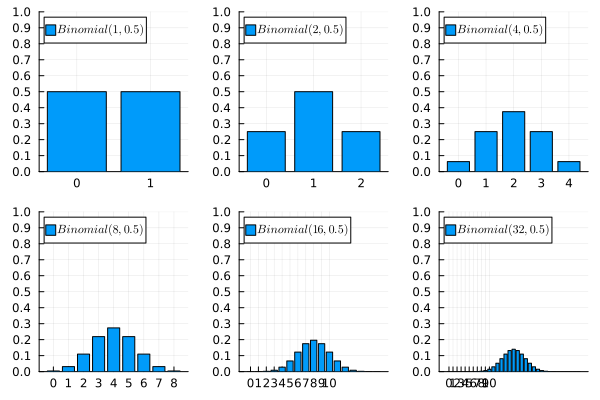

In [23]:
plot(binomial_pdf.((1, 2, 4, 8, 16, 32))...)

When $ n = 1 $, the distribution is flat — one success or no successes
have the same probability.

When $ n = 2 $ we can either have 0, 1 or 2 successes.

Notice the peak in probability mass at the mid-point $ k=1 $.

The reason is that there are more ways to get 1 success (“fail then succeed”
or “succeed then fail”) than to get zero or two successes.

Moreover, the two trials are independent, so the outcomes “fail then succeed” and “succeed then
fail” are just as likely as the outcomes “fail then fail” and “succeed then succeed”.

(If there was positive correlation, say, then “succeed then fail” would be less likely than “succeed then succeed”)

Here, already we have the essence of the CLT: addition under independence leads probability mass to pile up in the middle and thin out at the tails.

For $ n = 4 $ and $ n = 8 $ we again get a peak at the “middle” value (halfway between the minimum and the maximum possible value).

The intuition is the same — there are simply more ways to get these middle outcomes.

If we continue, the bell-shaped curve becomes ever more pronounced.

We are witnessing the [binomial approximation of the normal distribution](https://en.wikipedia.org/wiki/De_Moivre%E2%80%93Laplace_theorem).

### Simulation 1

Since the CLT seems almost magical, running simulations that verify its implications is one good way to build intuition.

To this end, we now perform the following simulation

1. Choose an arbitrary distribution $ F $ for the underlying observations $ X_i $.  
1. Generate independent draws of $ Y_n := \sqrt{n} ( \bar X_n - \mu ) $.  
1. Use these draws to compute some measure of their distribution — such as a histogram.  
1. Compare the latter to $ N(0, \sigma^2) $.  


Here’s some code that does exactly this for the exponential distribution
$ F(x) = 1 - e^{- \lambda x} $.

(Please experiment with other choices of $ F $, but remember that, to conform with the conditions of the CLT, the distribution must have finite second moment)

In [25]:
using StatsPlots

function simulation1(distribution, n = 250, k = 10_000)
    sigma = std(distribution)
    y = rand(distribution, n, k)
    y .-= mean(distribution)
    y = mean(y, dims = 1)
    y = √n * vec(y)
    density(y, label = "Empirical Distribution")
    return plot!(Normal(0, sigma), linestyle = :dash, color = :black,
                 label = L"Normal(0.00, %$(sigma^2))")
end


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


simulation1 (generic function with 3 methods)

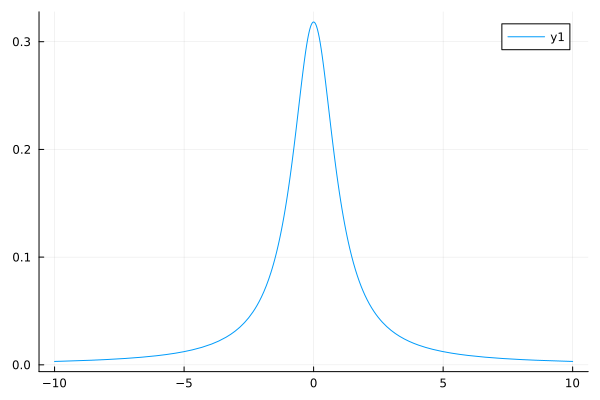

In [43]:
plot(x -> pdf(Cauchy(), x), -10, 10)

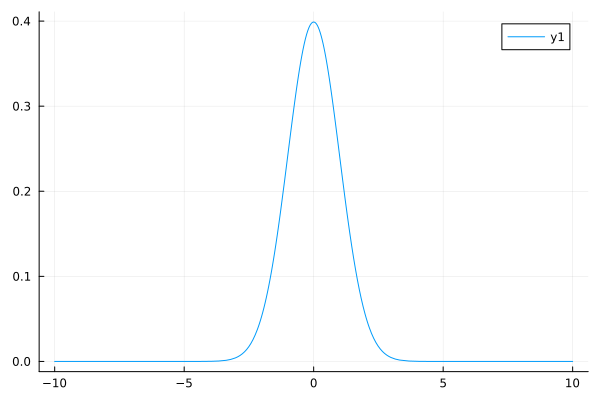

In [44]:
plot(x -> pdf(Normal(), x), -10, 10)

The fit to the normal density is already tight, and can be further improved by increasing `n`.

You can also experiment with other specifications of $ F $.

### Simulation 2

Our next simulation is somewhat like the first, except that we aim to track the distribution of $ Y_n := \sqrt{n} ( \bar X_n - \mu ) $ as $ n $ increases.

In the simulation we’ll be working with random variables having $ \mu = 0 $.

Thus, when $ n=1 $, we have $ Y_1 = X_1 $, so the first distribution is just
the distribution of the underlying random variable.

For $ n=2 $, the distribution of $ Y_2 $ is that of $ (X_1 + X_2) / \sqrt{2} $, and so on.

What we expect is that, regardless of the distribution of the underlying
random variable, the distribution of $ Y_n $ will smooth out into a bell
shaped curve.

The next figure shows this process for $ X_i \sim f $, where $ f $ was
specified as the convex combination of three different beta densities.

(Taking a convex combination is an easy way to produce an irregular shape for $ f $)

In [29]:
function simulation2(distribution = Beta(2, 2), n = 5, k = 10_000)
    y = rand(distribution, k, n)
    for col in 1:n
        y[:, col] += rand([-0.5, 0.6, -1.1], k)
    end
    y = (y .- mean(distribution)) ./ std(distribution)
    y = cumsum(y, dims = 2) ./ sqrt.(1:5)' # return grid of data
end

simulation2 (generic function with 4 methods)

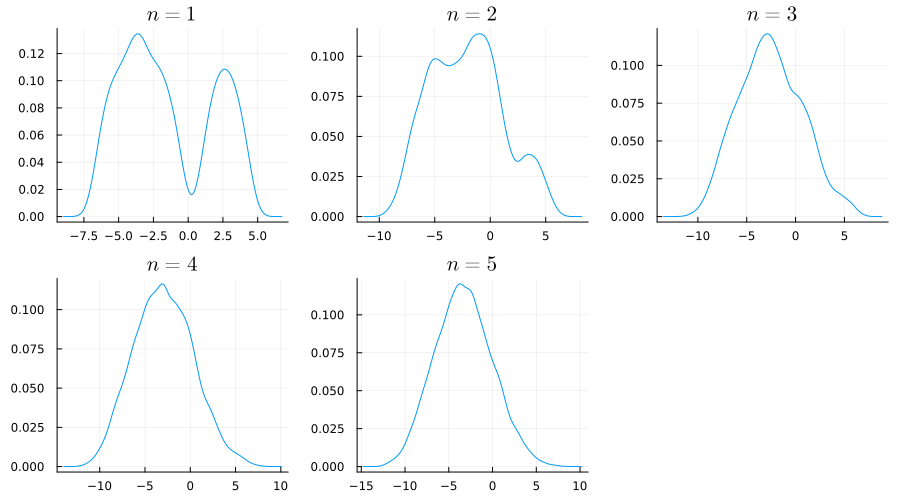

In [30]:
ys = simulation2()
plots = [] # would preallocate in optimized code
for i in 1:size(ys, 2)
    p = density(ys[:, i], linealpha = i, title = L"n = %$i")
    push!(plots, p)
end

plot(plots..., legend = false, size = (900, 500))

As expected, the distribution smooths out into a bell curve as $ n $ increases.

We leave you to investigate its contents if you wish to know more.


<a id='multivariate-clt'></a>

### The Multivariate Case


<a id='index-10'></a>
The law of large numbers and central limit theorem work just as nicely in multidimensional settings.

To state the results, let’s recall some elementary facts about random vectors.

A random vector $ \mathbf X $ is just a sequence of $ k $ random variables $ (X_1, \ldots, X_k) $.

Each realization of $ \mathbf X $ is an element of $ \mathbb R^k $.

A collection of random vectors $ \mathbf X_1, \ldots, \mathbf X_n $ is called independent if, given any $ n $ vectors $ \mathbf x_1, \ldots, \mathbf x_n $ in $ \mathbb R^k $, we have

$$
\mathbb P\{\mathbf X_1 \leq \mathbf x_1,\ldots, \mathbf X_n \leq \mathbf x_n \}
= \mathbb P\{\mathbf X_1 \leq \mathbf x_1 \}
\times \cdots \times \mathbb P\{ \mathbf X_n \leq \mathbf x_n \}
$$

(The vector inequality $ \mathbf X \leq \mathbf x $ means that $ X_j \leq x_j $ for $ j = 1,\ldots,k $)

Let $ \mu_j := \mathbb E [X_j] $ for all $ j =1,\ldots,k $.

The expectation $ \mathbb E [\mathbf X] $ of $ \mathbf X $ is defined to be the vector of expectations:

$$
\mathbb E [\mathbf X]
:=
\left(
\begin{array}{c}
    \mathbb E [X_1] \\
    \mathbb E [X_2] \\
    \vdots \\
    \mathbb E [X_k]
\end{array}
\right)
=
\left(
\begin{array}{c}
    \mu_1 \\
    \mu_2\\
    \vdots \\
    \mu_k
\end{array}
\right)
=: \boldsymbol \mu
$$

The *variance-covariance matrix* of random vector $ \mathbf X $ is defined as

$$
\mathop{\mathrm{Var}}[\mathbf X]
:= \mathbb E
[ (\mathbf X - \boldsymbol \mu) (\mathbf X - \boldsymbol \mu)']
$$

Expanding this out, we get

$$
\mathop{\mathrm{Var}}[\mathbf X]
=
\left(
\begin{array}{ccc}
    \mathbb E [(X_1 - \mu_1)(X_1 - \mu_1)]
        & \cdots & \mathbb E [(X_1 - \mu_1)(X_k - \mu_k)] \\
    \mathbb E [(X_2 - \mu_2)(X_1 - \mu_1)]
        & \cdots & \mathbb E [(X_2 - \mu_2)(X_k - \mu_k)] \\
    \vdots & \vdots & \vdots \\
    \mathbb E [(X_k - \mu_k)(X_1 - \mu_1)]
        & \cdots & \mathbb E [(X_k - \mu_k)(X_k - \mu_k)] \\
\end{array}
\right)
$$

The $ j,k $-th term is the scalar covariance between $ X_j $ and
$ X_k $.

With this notation we can proceed to the multivariate LLN and CLT.

Let $ \mathbf X_1, \ldots, \mathbf X_n $ be a sequence of independent and
identically distributed random vectors, each one taking values in
$ \mathbb R^k $.

Let $ \boldsymbol \mu $ be the vector $ \mathbb E [\mathbf X_i] $, and let $ \Sigma $
be the variance-covariance matrix of $ \mathbf X_i $.

Interpreting vector addition and scalar multiplication in the usual way (i.e., pointwise), let

$$
\bar{\mathbf X}_n := \frac{1}{n} \sum_{i=1}^n \mathbf X_i
$$

In this setting, the LLN tells us that


<a id='equation-lln-asmv'></a>
$$
\mathbb P \left\{ \bar{\mathbf X}_n \to \boldsymbol \mu \text{ as } n \to \infty \right\} = 1 \tag{18.7}
$$

Here $ \bar{\mathbf X}_n \to \boldsymbol \mu $ means that $ \| \bar{\mathbf X}_n - \boldsymbol \mu \| \to 0 $, where $ \| \cdot \| $ is the standard Euclidean norm.

The CLT tells us that, provided $ \Sigma $ is finite,


<a id='equation-lln-cltmv'></a>
$$
\sqrt{n} ( \bar{\mathbf X}_n - \boldsymbol \mu ) \stackrel { d } {\to} N(\mathbf 0, \Sigma)
\quad \text{as} \quad
n \to \infty \tag{18.8}
$$

## Exercises


<a id='lln-ex1'></a>

### Exercise 1

One very useful consequence of the central limit theorem is as follows.

Assume the conditions of the CLT as [stated above](#statement-clt).

If $ g \colon \mathbb R \to \mathbb R $ is differentiable at $ \mu $ and $ g'(\mu) \not= 0 $, then


<a id='equation-lln-dm'></a>
$$
\sqrt{n} \{ g(\bar X_n) - g(\mu) \}
\stackrel { d } {\to} N(0, g'(\mu)^2 \sigma^2)
\quad \text{as} \quad
n \to \infty \tag{18.9}
$$

This theorem is used frequently in statistics to obtain the asymptotic distribution of estimators — many of which can be expressed as functions of sample means.

(These kinds of results are often said to use the “delta method”)

The proof is based on a Taylor expansion of $ g $ around the point $ \mu $.

Taking the result as given, let the distribution $ F $ of each $ X_i $ be uniform on $ [0, \pi / 2] $ and let $ g(x) = \sin(x) $.

Derive the asymptotic distribution of $ \sqrt{n} \{ g(\bar X_n) - g(\mu) \} $ and illustrate convergence in the same spirit as the program `illustrate_clt.jl` discussed above.

What happens when you replace $ [0, \pi / 2] $ with $ [0, \pi] $?

What is the source of the problem?


<a id='lln-ex2'></a>

### Exercise 2

Here’s a result that’s often used in developing statistical tests, and is connected to the multivariate central limit theorem.

If you study econometric theory, you will see this result used again and again.

Assume the setting of the multivariate CLT [discussed above](#multivariate-clt), so that

1. $ \mathbf X_1, \ldots, \mathbf X_n $ is a sequence of IID random vectors, each taking values in $ \mathbb R^k $  
1. $ \boldsymbol \mu := \mathbb E [\mathbf X_i] $, and $ \Sigma $ is the variance-covariance matrix of $ \mathbf X_i $  
1. The convergence  



<a id='equation-lln-cltmv2'></a>
$$
\sqrt{n} ( \bar{\mathbf X}_n - \boldsymbol \mu ) \stackrel { d } {\to} N(\mathbf 0, \Sigma) \tag{18.10}
$$

is valid.

In a statistical setting, one often wants the right hand side to be **standard** normal, so that confidence intervals are easily computed.

This normalization can be achieved on the basis of three observations.

First, if $ \mathbf X $ is a random vector in $ \mathbb R^k $ and $ \mathbf A $ is constant and $ k \times k $, then

$$
\mathop{\mathrm{Var}}[\mathbf A \mathbf X]
= \mathbf A \mathop{\mathrm{Var}}[\mathbf X] \mathbf A'
$$

Second, by the [continuous mapping theorem](https://en.wikipedia.org/wiki/Continuous_mapping_theorem), if $ \mathbf Z_n \stackrel{d}{\to} \mathbf Z $ in $ \mathbb R^k $ and $ \mathbf A $ is constant and $ k \times k $, then

$$
\mathbf A \mathbf Z_n
\stackrel{d}{\to} \mathbf A \mathbf Z
$$

Third, if $ \mathbf S $ is a $ k \times k $ symmetric positive definite matrix, then there
exists a symmetric positive definite matrix $ \mathbf Q $, called the inverse
[square root](https://en.wikipedia.org/wiki/Square_root_of_a_matrix) of $ \mathbf S $, such that

$$
\mathbf Q \mathbf S\mathbf Q' = \mathbf I
$$

Here $ \mathbf I $ is the $ k \times k $ identity matrix.

Putting these things together, your first exercise is to show that if
$ \mathbf Q $ is the inverse square root of $ \mathbf \Sigma $, then

$$
\mathbf Z_n := \sqrt{n} \mathbf Q ( \bar{\mathbf X}_n - \boldsymbol \mu )
\stackrel{d}{\to}
\mathbf Z \sim N(\mathbf 0, \mathbf I)
$$

Applying the continuous mapping theorem one more time tells us that

$$
\| \mathbf Z_n \|^2
\stackrel{d}{\to}
\| \mathbf Z \|^2
$$

Given the distribution of $ \mathbf Z $, we conclude that


<a id='equation-lln-ctc'></a>
$$
n \| \mathbf Q ( \bar{\mathbf X}_n - \boldsymbol \mu ) \|^2
\stackrel{d}{\to}
\chi^2(k) \tag{18.11}
$$

where $ \chi^2(k) $ is the chi-squared distribution with $ k $ degrees
of freedom.

(Recall that $ k $ is the dimension of $ \mathbf X_i $, the underlying random vectors)

Your second exercise is to illustrate the convergence in [(18.11)](#equation-lln-ctc) with a simulation.

In doing so, let

$$
\mathbf X_i
:=
\left(
\begin{array}{c}
    W_i \\
    U_i + W_i
\end{array}
\right)
$$

where

- each $ W_i $ is an IID draw from the uniform distribution on $ [-1, 1] $  
- each $ U_i $ is an IID draw from the uniform distribution on $ [-2, 2] $  
- $ U_i $ and $ W_i $ are independent of each other  


Hints:

1. `sqrt(A::AbstractMatrix{<:Number})` computes the square root of `A`.  You still need to invert it.  
1. You should be able to work out $ \Sigma $ from the proceeding information.  

## Solutions

### Exercise 1

Here is one solution

In [ ]:
function exercise1(distribution = Uniform(0, π / 2); n = 250, k = 10_000, g = sin,
                   g′ = cos)
    mu, sigma = mean(distribution), std(distribution)
    y = rand(distribution, n, k)
    y = mean(y, dims = 1)
    y = vec(y)
    error_obs = sqrt(n) .* (g.(y) .- g.(mu))
    density(error_obs, label = "Empirical Density")
    return plot!(Normal(0, g′(mu) .* sigma), linestyle = :dash,
                 label = "Asymptotic",
                 color = :black)
end
exercise1()

What happens when you replace $ [0, \pi / 2] $ with
$ [0, \pi] $?

In this case, the mean $ \mu $ of this distribution is
$ \pi/2 $, and since $ g' = \cos $, we have $ g'(\mu) = 0 $.

Hence the conditions of the delta theorem are not satisfied.

### Exercise 2

First we want to verify the claim that

$$
\sqrt{n} \mathbf Q ( \bar{\mathbf X}_n - \boldsymbol \mu )
\stackrel{d}{\to}
N(\mathbf 0, \mathbf I)
$$

This is straightforward given the facts presented in the exercise.

Let

$$
\mathbf Y_n := \sqrt{n} ( \bar{\mathbf X}_n - \boldsymbol \mu )
\quad \text{and} \quad
\mathbf Y \sim N(\mathbf 0, \Sigma)
$$

By the multivariate CLT and the continuous mapping theorem, we have

$$
\mathbf Q \mathbf Y_n
\stackrel{d}{\to}
\mathbf Q \mathbf Y
$$

Since linear combinations of normal random variables are normal, the
vector $ \mathbf Q \mathbf Y $ is also normal.

Its mean is clearly $ \mathbf 0 $, and its variance covariance
matrix is

$$
\mathrm{Var}[\mathbf Q \mathbf Y]
= \mathbf Q \mathrm{Var}[\mathbf Y] \mathbf Q'
= \mathbf Q \Sigma \mathbf Q'
= \mathbf I
$$

In conclusion,
$ \mathbf Q \mathbf Y_n \stackrel{d}{\to} \mathbf Q \mathbf Y \sim N(\mathbf 0, \mathbf I) $,
which is what we aimed to show.

Now we turn to the simulation exercise.

Our solution is as follows

In [ ]:
function exercise2(; n = 250, k = 50_000, dw = Uniform(-1, 1), du = Uniform(-2, 2))
    vw = var(dw)
    vu = var(du)
    Sigma = [vw vw
             vw vw+vu]
    Q = inv(sqrt(Sigma))
    function generate_data(dw, du, n)
        dw = rand(dw, n)
        X = [dw dw + rand(du, n)]
        return sqrt(n) * mean(X, dims = 1)
    end
    X = mapreduce(x -> generate_data(dw, du, n), vcat, 1:k)
    X = Q * X'
    X = sum(abs2, X, dims = 1)
    X = vec(X)
    density(X, label = "", xlim = (0, 10))
    return plot!(Chisq(2), color = :black, linestyle = :dash,
                 label = "Chi-squared with 2 degrees of freedom", grid = false)
end
exercise2()